In [9]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

# my utils
from utils import preprocess_listings

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}



x_vars=["host_identity_verified",      
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",#"number_of_reviews_till_Q",
    "host_is_superhost","years_since_host","professional_host", ##'calculated_host_listings_count',
    "host_response_rate","host_response_time",
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "text_length",
    "price","availability_90","room_type", "instant_bookable", #'is_within_1km'
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type",'pic_no_person','pic_pro_style','pic_life_style',
    "is_smiling","age_class","gender",
    "in_paris",'in_2024'
]  
print(len(x_vars))


29


In [2]:
path_df="../data_processed\listings_tactics_bio_vis-paris_london-2306_2406_ols.csv"
df=pd.read_csv(path_df)
print(df.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_4980\131809557.py:2: DtypeWarning: Columns (68) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df)


(187851, 128)


In [3]:
df.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [ ]:
tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactic_pic=["host_picture_type","is_smiling"]
vars_person=['age_class','gender']

In [11]:
vars_ctrl_num=[v for v in x_vars if  pd.api.types.is_any_real_numeric_dtype(df[v])]
vars_ctrl_cat=[v for v in x_vars if  v not in vars_ctrl_num]

print(len(vars_ctrl_num), len(vars_ctrl_cat))
print(vars_ctrl_num)
print(vars_ctrl_cat)

21 8
['review_scores_rating', 'has_rating', 'number_of_reviews_ltm', 'host_is_superhost', 'years_since_host', 'professional_host', 'host_response_rate', 'text_length', 'price', 'availability_90', 'ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité', 'pic_no_person', 'pic_pro_style', 'pic_life_style', 'is_smiling', 'in_paris', 'in_2024']
['host_identity_verified', 'host_response_time', 'lang', 'room_type', 'instant_bookable', 'host_picture_type', 'age_class', 'gender']


In [ ]:
df.instant_bookable.value_counts(dropna=False)
df.host_identity_verified.value_counts(dropna=False)


instant_bookable
f    134293
t     53558
Name: count, dtype: int64

## desc 2 groups:


In [7]:
## traitement vs control (paris vs london)
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest
 
tactics = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
    # "host_picture_type",
    # "is_smiling"
]

vars_ctrl_num=[
    "booking_rate_l90d","review_scores_rating","has_rating","number_of_reviews_ltm",
    "years_since_host",
    "host_response_rate",
    "text_length",
    "price","availability_90","instant_bookable", #'is_within_1km'
    "in_2024"
]
cols_to_check=vars_ctrl_num+tactics

group_mean_table_ttest(df, cols_to_check, group_col='in_paris',        
                    save=False, output_folder="mod_results", filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 187851 lines.

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 instant_bookable



in_paris,0,1,ttest_p,significance
proportion,0.490878,0.509122,NaN,NaN
booking_rate_l90d,0.139261,0.12348,0.0,***
review_scores_rating,4.716751,4.751896,0.0,***
has_rating,0.774747,0.734826,0.0,***
number_of_reviews_ltm,8.892075,8.621734,0.00017,***
years_since_host,6.701731,7.038572,0.0,***
host_response_rate,0.842833,0.720017,0.0,***
text_length,33.923969,28.198402,0.0,***
price,218.257157,270.618011,0.0,***
availability_90,48.09913,46.223256,0.0,***


In [ ]:
group_mean_table_ttest(df, cols_to_check, group_col='in_2024',        
                    save=False, output_folder="mod_results", filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 187851 lines.

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 instant_bookable



in_2024,0,1,ttest_p,significance
proportion,0.400621,0.599379,NaN,NaN
booking_rate_l90d,0.18498,0.095298,0.0,***
review_scores_rating,4.698738,4.758644,0.0,***
has_rating,0.802636,0.722197,0.0,***
number_of_reviews_ltm,10.032024,7.90051,0.0,***
years_since_host,7.220298,6.641242,0.0,***
host_response_rate,0.813871,0.757869,0.0,***
text_length,34.644126,28.57924,0.0,***
price,235.316954,251.330595,0.0,***
availability_90,42.754056,50.078343,0.0,***


## desc 4 groups

['host_identity_verified', 'host_response_time', 'lang', 'room_type', 'instant_bookable', 'host_picture_type', 'age_class', 'gender']


In [43]:
from scipy import stats
import pandas as pd

df["group"] = (
    df["in_paris"].astype(str) + "_" + df["in_2024"].astype(str)
)
groups = df["group"].astype(str).unique()

def ttest(a, b):
    return stats.ttest_ind(a.dropna(), b.dropna()).pvalue


tactics = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
    # "host_picture_type",
    # "is_smiling"
]

vars_ctrl_num=[
    "booking_rate_l90d","review_scores_rating","has_rating","number_of_reviews_ltm",
    "years_since_host",
    "host_response_rate",
    "text_length",
    "price","availability_90",#"instant_bookable", #'is_within_1km'
]

table = []
for var in vars_ctrl_num + tactics:
    if not pd.api.types.is_numeric_dtype(df[var]):
        print(f"{var} not numeric!")
        continue
    
    row = {"variable numérique: mean(std)": var}
    
    for g in groups:
        
        sub = df[df["group"] == g][var]    
        city="paris" if g.split("_")[0]=="1" else "london"
        time="2024" if  g.split("_")[1]=="1" else "2023"
        row[f"{city} {time}"] = f"{sub.mean():.2f} ({sub.std():.2f})"     

    table.append(row)

table1 = pd.DataFrame(table)
table1

,variable numérique: mean(std),london 2023,london 2024,paris 2023,paris 2024
0,booking_rate_l90d,0.16 (0.27),0.12 (0.22),0.21 (0.31),0.08 (0.16)
1,review_scores_rating,4.70 (0.49),4.73 (0.39),4.70 (0.44),4.78 (0.31)
2,has_rating,0.78 (0.42),0.77 (0.42),0.83 (0.37),0.68 (0.47)
3,number_of_reviews_ltm,9.22 (15.95),8.62 (14.82),11.08 (18.69),7.33 (13.90)
4,years_since_host,7.06 (3.32),6.40 (3.68),7.42 (3.38),6.84 (3.76)
5,host_response_rate,0.85 (0.32),0.84 (0.34),0.77 (0.39),0.69 (0.44)
6,text_length,35.59 (62.10),32.51 (58.48),33.42 (65.45),25.46 (51.38)
7,price,226.77 (527.16),211.02 (876.68),246.32 (570.70),283.36 (682.86)
8,availability_90,45.54 (28.53),50.27 (27.62),39.17 (27.22),49.92 (25.13)
9,ouverture,-0.10 (0.69),-0.10 (0.67),-0.09 (0.65),-0.08 (0.61)


In [25]:
from scipy import stats
import pandas as pd

df["group"] = df["host_picture_type"]


##
groups = df["group"].astype(str).unique()
print(groups)

def ttest(a, b):
    return stats.ttest_ind(a.dropna(), b.dropna()).pvalue


tactics = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
    # "host_picture_type",
    "is_smiling"
]

vars_ctrl_num=[
    "booking_rate_l90d","review_scores_rating","has_rating","number_of_reviews_ltm",
    "years_since_host",
    "host_response_rate",
    "text_length",
    "price","availability_90","instant_bookable", #'is_within_1km'
]
vars_ctrl_cat=["host_response_time"]

table = []
for var in vars_ctrl_num + tactics:
    if not pd.api.types.is_numeric_dtype(df[var]):
        print(f"{var} not numeric!")
        continue
    
    row = {"variable numérique: mean(std)": var}
    
    for g in groups:
        sub = df[df["group"] == g][var]            
        row[f"{g}"] = f"{sub.mean():.2f} ({sub.std():.2f})"
        
        # break
    # break
    table.append(row)

table2 = pd.DataFrame(table)
table2



['life_style' 'pro_style' 'no_person']


,variable numérique: mean(std),life_style,pro_style,no_person
0,booking_rate_l90d,0.15 (0.25),0.15 (0.25),0.09 (0.19)
1,review_scores_rating,4.77 (0.35),4.78 (0.35),4.65 (0.48)
2,has_rating,0.78 (0.41),0.78 (0.41),0.70 (0.46)
3,number_of_reviews_ltm,9.18 (14.76),9.31 (14.71),7.79 (17.08)
4,years_since_host,7.82 (3.23),7.65 (3.33),5.23 (3.60)
5,host_response_rate,0.78 (0.38),0.78 (0.39),0.78 (0.38)
6,text_length,28.98 (55.26),25.53 (46.90),38.54 (70.33)
7,price,222.29 (742.24),206.77 (407.12),304.89 (860.92)
8,availability_90,43.67 (27.25),44.32 (27.25),53.18 (26.26)
9,instant_bookable,0.00 (0.00),0.00 (0.00),0.00 (0.00)


## desc vars cat

In [24]:
import pandas as pd

# # 计算每个变量的比例
# df_list = []

# for col in vars_ctrl_cat:
#     temp = (
#         df[col]
#         .value_counts(normalize=True)
#         .reset_index()
#     )
#     temp.columns = ['category', 'percentage']
#     temp['variable'] = col
#     df_list.append(temp)

# df_plot = pd.concat(df_list)
df_list = []

for col in vars_ctrl_cat:
    temp = (
        df[col]
        .value_counts(normalize=True)
        .reset_index()
    )

    temp.columns = ['category', 'percentage']
    temp['variable'] = col

    df_list.append(temp)

df_plot = pd.concat(df_list, ignore_index=True)
df_plot

,category,percentage,variable
0,t,0.928736,host_identity_verified
1,f,0.071264,host_identity_verified
2,within an hour,0.537048,host_response_time
3,no_response_time,0.166243,host_response_time
4,within a few hours,0.162198,host_response_time
5,within a day,0.104024,host_response_time
6,a few days or more,0.030487,host_response_time
7,no_text,0.503223,lang
8,en,0.356123,lang
9,fr,0.130806,lang


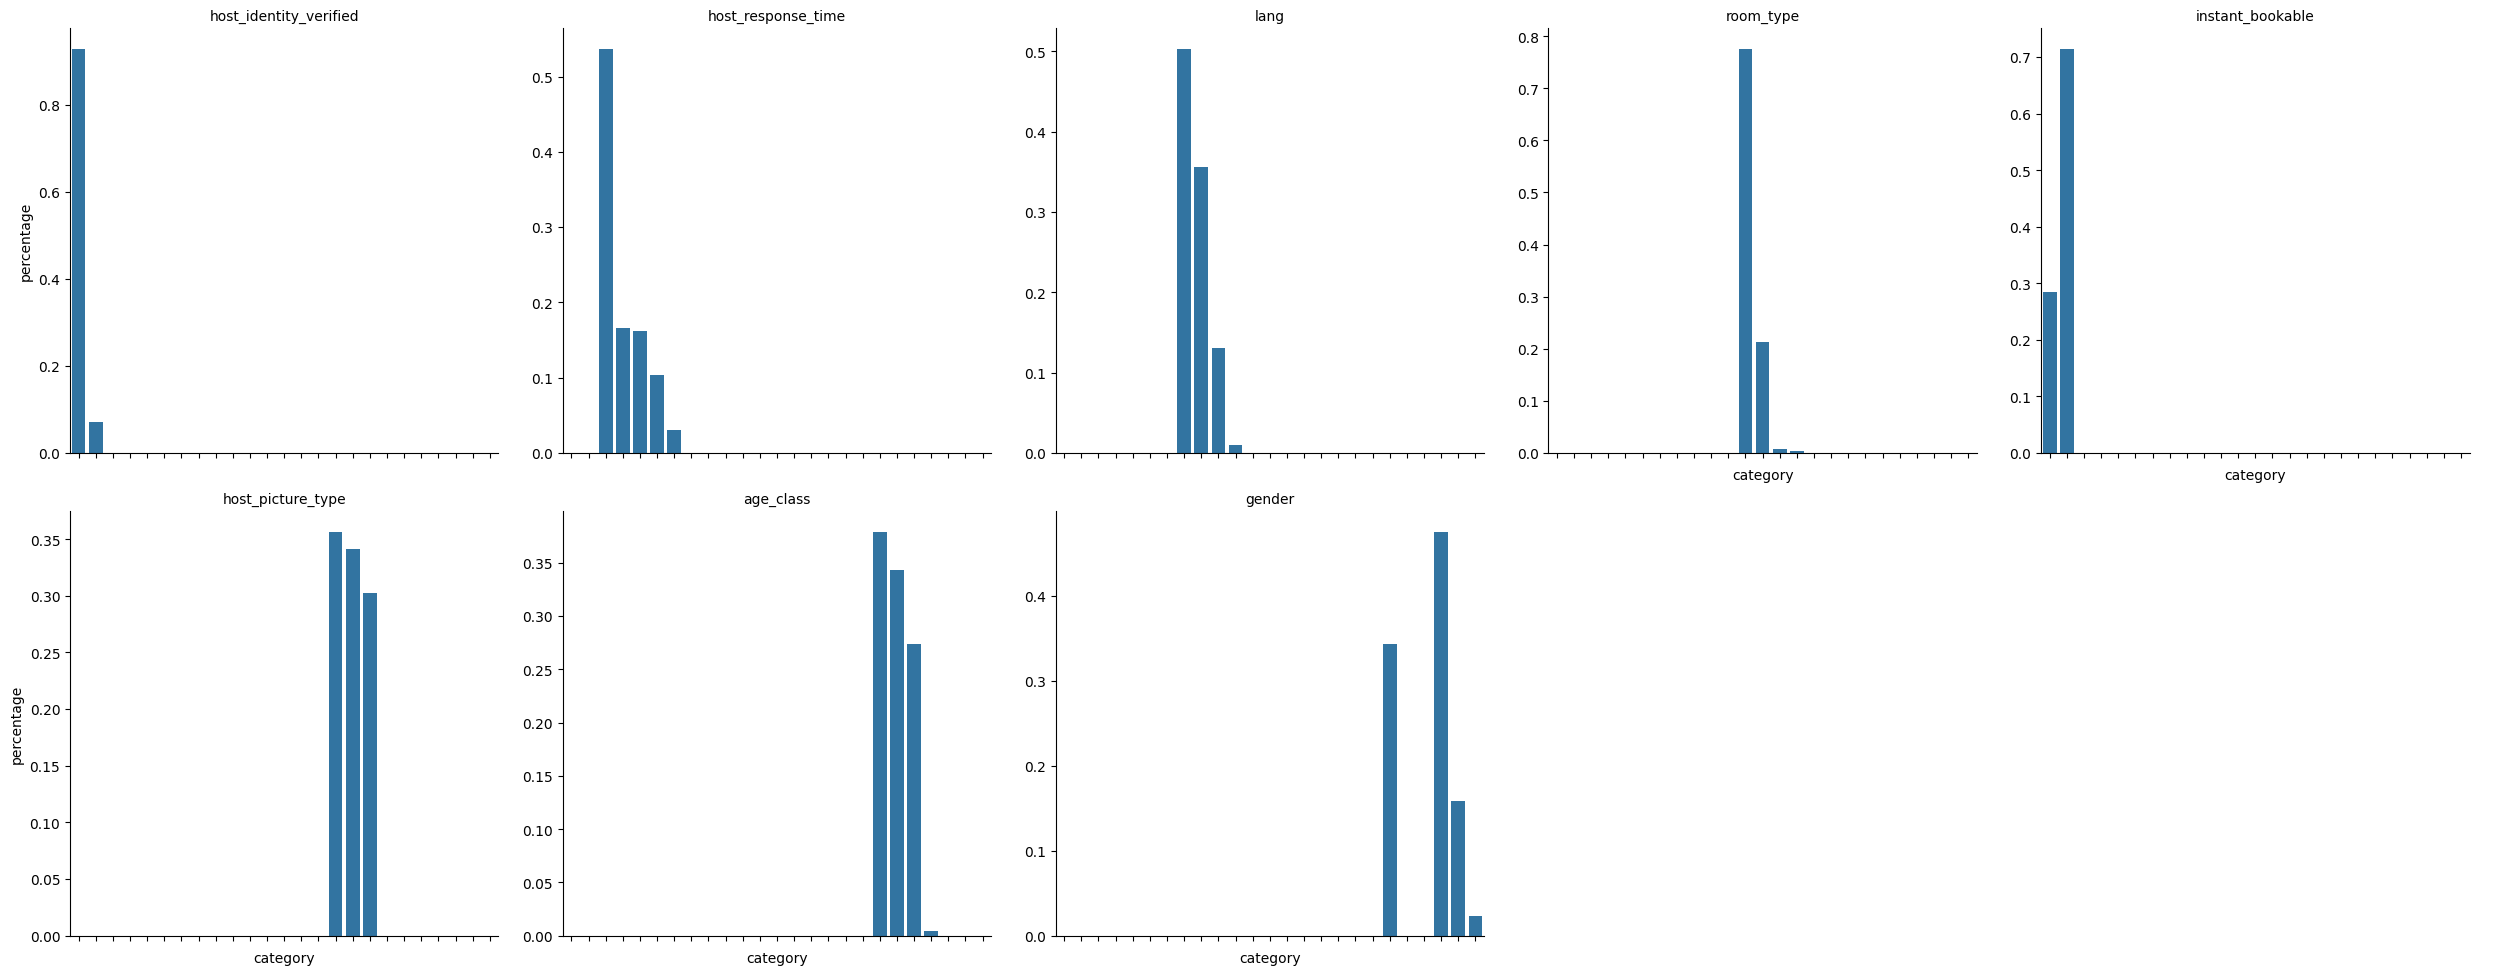

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df_plot,
    x="category",
    y="percentage",
    col="variable",
    kind="bar",
    col_wrap=5,   # 每行3个图
    sharey=False  # 每个变量自己的尺度
)

g.set_titles("{col_name}")
g.set_xticklabels(rotation=45)

plt.show()

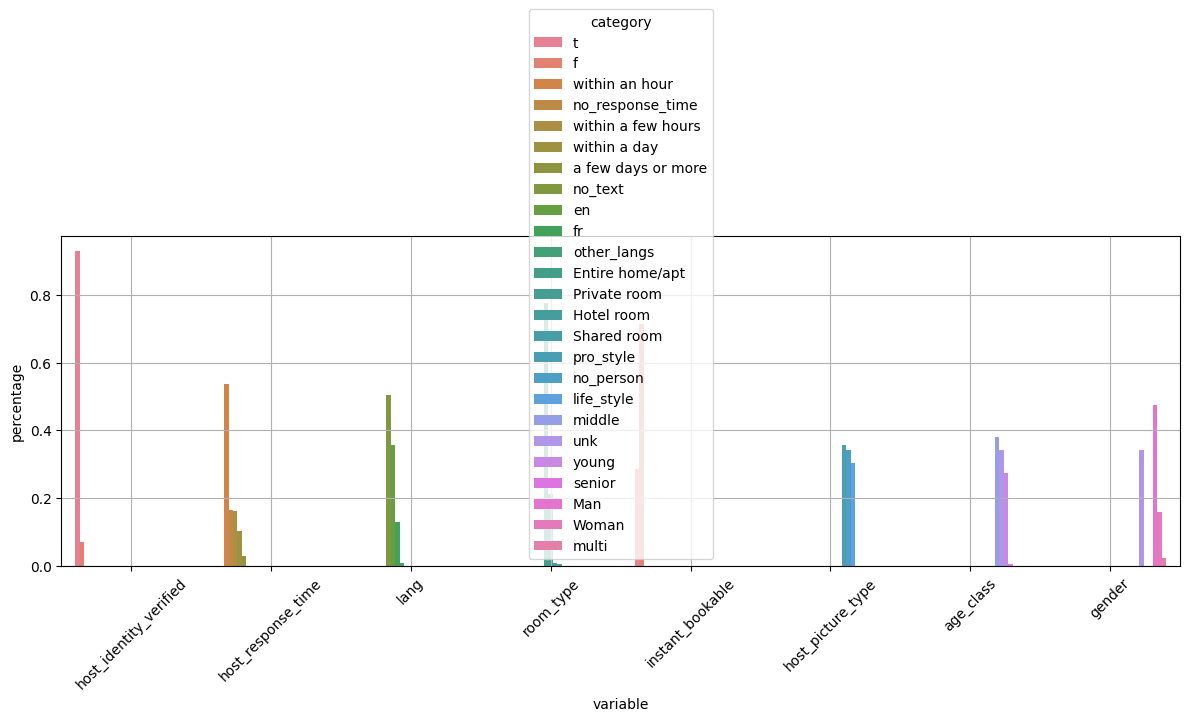

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))

# df[col].value_counts(normalize=True).sort_values(ascending=False)

sns.barplot(
    data=df_plot,
    x="variable",
    y="percentage",
    hue="category",
)

plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

## distribution de booking rate

[INFO] groups: ['0_0' '0_1' '1_0' '1_1']


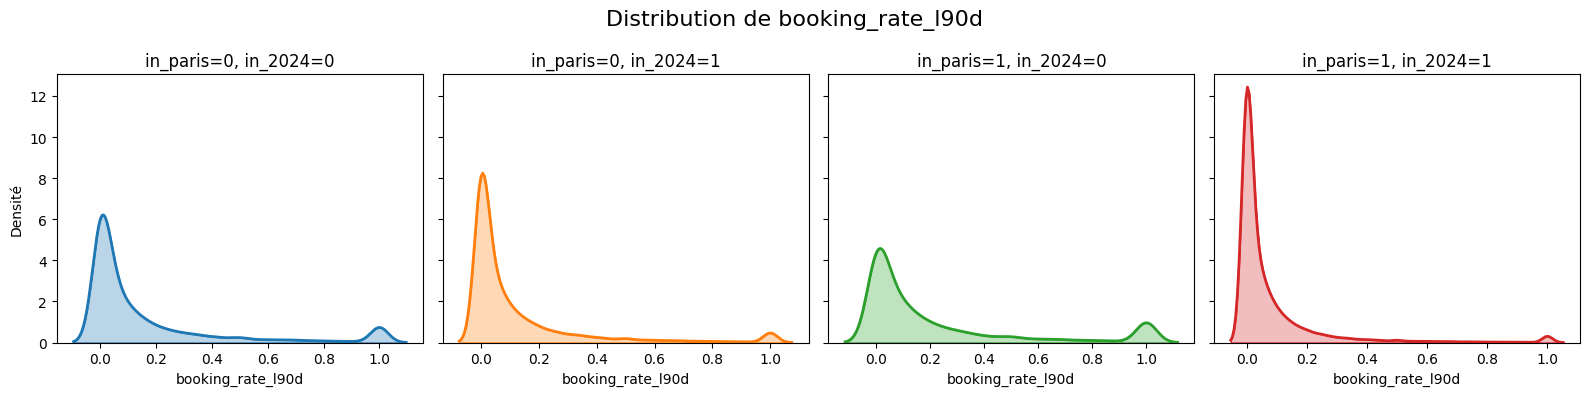

In [39]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import plot_distribution
plot_distribution(
    df, 
    group_cols=['in_paris','in_2024'], 
    y_var='booking_rate_l90d',
    save=False, 
    output_folder="mod_results",
    filename=None)

In [43]:
df[tactics_bio].describe()

,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
count,92339.000000,92339.000000,92339.000000,92339.000000,92339.000000
mean,-0.182682,-0.372649,-0.135705,0.307224,0.053699
std,0.921622,0.991799,0.973321,0.999546,0.951822
min,-1.899298,-2.072260,-2.165260,-1.688499,-0.861799
25%,-0.984279,-1.332886,-1.039574,-0.624391,-0.612170
50%,-0.263486,-0.451861,0.032526,0.520209,-0.421510
75%,0.582050,0.515467,0.742395,1.189415,0.407699
max,1.793152,1.793233,1.518248,1.878054,2.876670


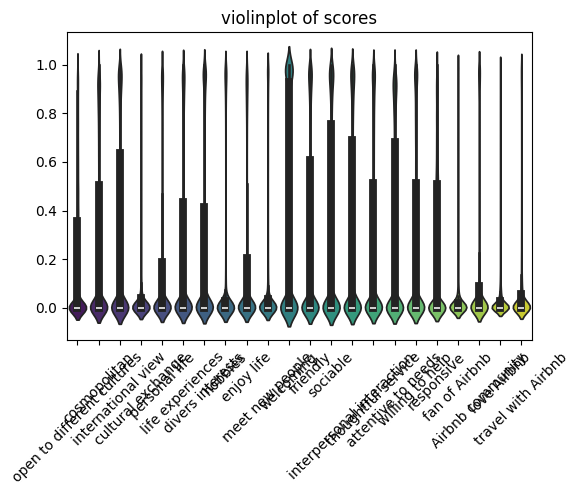

In [42]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import plot_violon

plot_violon(df_input=df, vars=LABELS_EN, to_fillna0=True, save=False, output_folder="../output_mod", filename="violon_tactics_weighted.jpg")
